# Distributions

Choosing the right distribution depends on theory and empirical observations. Different distribution suits different applications such as Credit Defaulting, Option pricing, Jump Processes, forecasting etc.


## Conjugate Distributions

In Bayesian probability theory, if the posterior distributions p(θ | x) are in the same probability distribution family as the prior probability distribution p(θ), the prior and posterior are then called conjugate distributions, and the prior is called a conjugate prior for the likelihood function. Conjugate prior, wikipedia

In [6]:
import random
import operator as op
from functools import reduce

import numpy as np
import matplotlib.pyplot as plt

## Uniform Distribution

Same probability distribution for all values in $[a, b]$

Standard Uniform: 
$$p(x) = \begin{cases} 1, \quad x \in [0,1], \\ 0, \quad \text{otherwise}\end{cases}$$

$P(a < X < b) = \int_a^b p(x) d(x) = b - a $

$F(x) = \int_{-\infty}^x p(x') dx' = x$

Moments

- $\mu = \int_{-\infty}^{\infty} x p(x) dx = \int_0^1 x dx = 1/2$
- $\mu_l = \int_0^1 x^l dx = \frac{1}{l+1}$
- $\sigma^2 =\int_0^1 (x-1/2)^2 dx = 1/12 $

Uniform distribution is symmetrical hence skewness is 0.

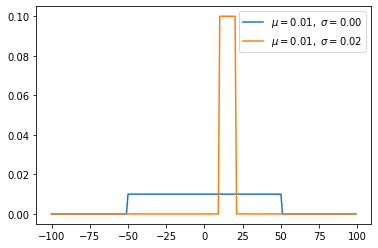

In [3]:
def uniform(x, a, b):

    y = [1 / (b - a) if a <= val and val <= b else 0 for val in x]

    return x, y, np.mean(y), np.std(y)

x = np.arange(-100, 100) # define range of x
for ls in [(-50, 50), (10, 20)]:
    a, b = ls[0], ls[1]
    x, y, u, s = uniform(x, a, b)
    plt.plot(x, y, label=r'$\mu=%.2f,\ \sigma=%.2f$' % (u, s))

plt.legend()
#plt.savefig('graph/uniform.png')
plt.show()

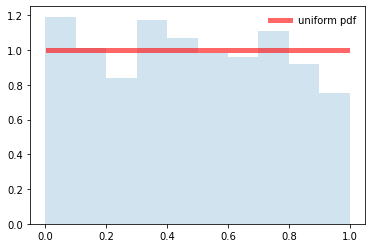

In [11]:
from scipy.stats import uniform
mean, var, skew, kurt = uniform.stats(moments='mvsk')

x = np.linspace(uniform.ppf(0.01), uniform.ppf(0.99), 100)

fig, ax = plt.subplots(1, 1)

ax.plot(x, uniform.pdf(x), 'r-', lw=5, alpha=0.6, label='uniform pdf')
r = uniform.rvs(size=1000)
ax.hist(r, density=True, histtype='stepfilled', alpha=0.2)
ax.legend(loc='best', frameon=False)
plt.show()

## Bernouli Distribution (Discrete)
Bernoulli distribution is not considered about prior probability P(X). Therefore, if we optimize to the maximum likelihood, we will be vulnerable to overfitting.
We use binary cross entropy to classify binary classification. It has same form like taking a negative log of the bernoulli distribution.


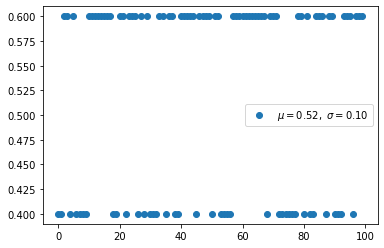

In [13]:
def bernoulli(p, k):
    return p if k else 1 - p

n_experiment = 100
p = 0.6
x = np.arange(n_experiment)
y = []
for _ in range(n_experiment):
    pick = bernoulli(p, k=bool(random.getrandbits(1)))
    y.append(pick)

u, s = np.mean(y), np.std(y)
plt.scatter(x, y, label=r'$\mu=%.2f,\ \sigma=%.2f$' % (u, s))
plt.legend()
#plt.savefig('graph/bernoulli.png')
plt.show()

## Binomial

Binomial distribution with parameters n and p is the discrete probability distribution of the number of successes in a sequence of n independent Bernoulli experiments. i.e it models for any observation that has two possible outcomes "success" or "failures". eg : coin toss, Roulette (#19 vs all other numbers), Bond default prior to time T vs no default, one day trading loss > $100M vs P/L > -$100M.
Binomial distribution is distribution considered prior probability by specifying the number to be picked in advance.

$$f(k; n, p) = \begin{pmatrix}n \\ k \end{pmatrix} p^k q^{n-k}, \quad \text{ where } q = 1 - p,\text{ and } \begin{pmatrix}n \\ k \end{pmatrix} = \begin{pmatrix}n \\ n-k \end{pmatrix}= \frac{n !} {k! (n-k)!}$$

Combinatorics and algebraic calculation $\mu = \mathbb E[X] = \sum_{k=0}^\infty k \frac{n !} {k! (n-k)!} p^k q^{n-k} = ... = np$  

View as number of "successes" as sum of random variables for multiple Bernoulli distribution: $\mathbb E[S] = \mathbb E[X_1] +\mathbb E[X_2] + \dots + \mathbb E[X_n] = np$

For Variance, X's are all IID

$\mathbb E[X_1] = p \cdot 1 + q \cdot 0 = p$

$\mathbb E[X_1 X_2] = p^2 \cdot 1 \cdot 1 + pq \cdot 1 \cdot 0 + qp \cdot 0 \cdot 1 + q^2 \cdot 0 \cdot 0 = p^2$

$\mathbb E[X_1 X_1] = \mathbb E[X_1^2] = p \cdot 1^2 + q \cdot 0^2 = p$


$\begin{aligned} \sigma^2 &= \mathbb E[(S - \mu)^2] \\ &= \mathbb E[(X_1 + X_2 + \dots + X_n)^2] - \mu^2 \\ &= n \mathbb E[X_1^2] + n(n-1) \mathbb E[X_1 X_2] - \mu^2 \\ &=np + n(n-1) p^2 - (np)^2 \\ &= np(1-p) \\ &= npq\end{aligned}$

$\sigma = \sqrt{npq}$

Suppose A is the average number of successes in n Bernoulli trials, $A = \frac{1}{n} \cdot (X_1 + X_2 + · · · + X_n)$ . What is the standard deviation of A ? 
Ans: $\sigma = \sqrt{npq}/n = \sqrt{pq/n}$


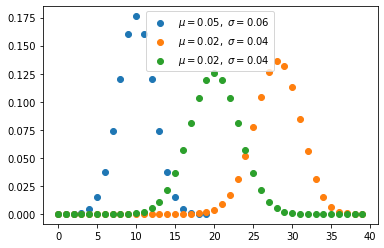

In [16]:
def const(n, r):
    r = min(r, n-r)
    numer = reduce(op.mul, range(n, n-r, -1), 1)
    denom = reduce(op.mul, range(1, r+1), 1)
    return numer / denom

def binomial(n, p):
    q = 1 - p
    y = [const(n, k) * (p ** k) * (q ** (n-k)) for k in range(n)]
    return y, np.mean(y), np.std(y)

for ls in [(0.5, 20), (0.7, 40), (0.5, 40)]:
    p, n_experiment = ls[0], ls[1]
    x = np.arange(n_experiment)
    y, u, s = binomial(n_experiment, p)
    plt.scatter(x, y, label=r'$\mu=%.2f,\ \sigma=%.2f$' % (u, s))

plt.legend()
#plt.savefig('graph/binomial.png')
plt.show()

[]

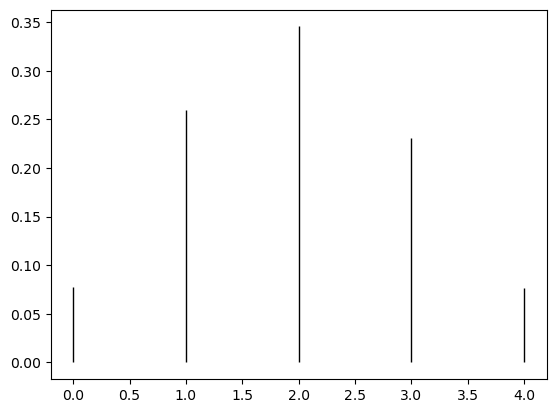

In [9]:
from scipy.stats import binom
n = 5
p = 0.4
rv = binom(n, p)
x = np.arange(binom.ppf(0.01, n, p),
              binom.ppf(0.99, n, p))
plt.vlines(x, 0, rv.pmf(x), colors='k', linestyles='-', lw=1,
        label='frozen pmf')
plt.plot()

## Multi-Bernoulli distribution, Categorical distribution(discrete)

Multi-bernoulli called categorical distribution, is a probability expanded more than 2.
cross entopy has same form like taking a negative log of the Multi-Bernoulli distribution.


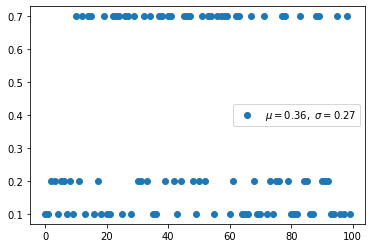

In [17]:
def categorical(p, k):
    return p[k]

n_experiment = 100
p = [0.2, 0.1, 0.7]
x = np.arange(n_experiment)
y = []
for _ in range(n_experiment):
    pick = categorical(p, k=random.randint(0, len(p) - 1))
    y.append(pick)

u, s = np.mean(y), np.std(y)
plt.scatter(x, y, label=r'$\mu=%.2f,\ \sigma=%.2f$' % (u, s))
plt.legend()
#plt.savefig('graph/categorical.png')
plt.show()

## Multinomial distribution(discrete)
The multinomial distribution has the same relationship with the categorical distribution as the relationship between Bernoull and Binomial.

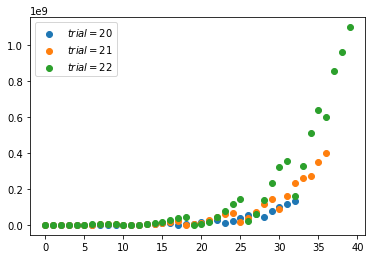

In [18]:
def factorial(n):
    return reduce(op.mul, range(1, n + 1), 1)

def const(n, a, b, c):
    """
        return n! / a! b! c!, where a+b+c == n
    """
    assert  a + b + c == n

    numer = factorial(n)
    denom = factorial(a) * factorial(b) * factorial(c)
    return numer / denom

def multinomial(n):
    """
    :param x : list, sum(x) should be `n`
    :param n : number of trial
    :param p: list, sum(p) should be `1`
    """
    # get all a,b,c where a+b+c == n, a<b<c
    ls = []
    for i in range(1, n + 1):
        for j in range(i, n + 1):
            for k in range(j, n + 1):
                if i + j + k == n:
                    ls.append([i, j, k])

    y = [const(n, l[0], l[1], l[2]) for l in ls]
    x = np.arange(len(y))
    return x, y, np.mean(y), np.std(y)

for n_experiment in [20, 21, 22]:
    x, y, u, s = multinomial(n_experiment)
    plt.scatter(x, y, label=r'$trial=%d$' % (n_experiment))

plt.legend()
#plt.savefig('graph/multinomial.png')
plt.show()

## Beta Distribution (Continuous)
Beta distribution is conjugate to the binomial and Bernoulli distributions.
Using conjucation, we can get the posterior distribution more easily using the prior distribution we know.
Uniform distiribution is same when beta distribution met special case(alpha=1, beta=1).

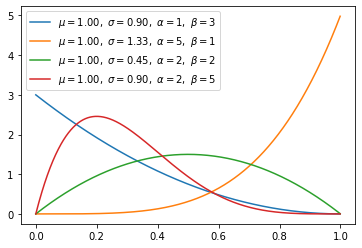

In [21]:
def gamma_function(n):
    cal = 1
    for i in range(2, n):
        cal *= i
    return cal

def beta(x, a, b):

    gamma = gamma_function(a + b) / \
            (gamma_function(a) * gamma_function(b))
    y = gamma * (x ** (a - 1)) * ((1 - x) ** (b - 1))
    return x, y, np.mean(y), np.std(y)

for ls in [(1, 3), (5, 1), (2, 2), (2, 5)]:
    a, b = ls[0], ls[1]

    # x in [0, 1], trial is 1/0.001 = 1000
    x = np.arange(0, 1, 0.001, dtype=float)
    x, y, u, s = beta(x, a=a, b=b)
    plt.plot(x, y, label=r'$\mu=%.2f,\ \sigma=%.2f,'
                         r'\ \alpha=%d,\ \beta=%d$' % (u, s, a, b))
plt.legend()
#plt.savefig('graph/beta.png')
plt.show()

## Dirichlet distribution(continuous)

Dirichlet distribution is conjugate to the MultiNomial distributions.
If k=2, it will be Beta distribution.

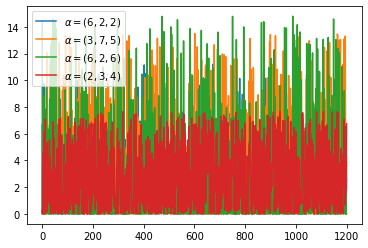

In [24]:
def normalization(x, s):
    """
    :return: normalizated list, where sum(x) == s
    """
    return [(i * s) / sum(x) for i in x]

def sampling():
    return normalization([random.randint(1, 100),
            random.randint(1, 100), random.randint(1, 100)], s=1)

def gamma_function(n):
    cal = 1
    for i in range(2, n):
        cal *= i
    return cal

def beta_function(alpha):
    """
    :param alpha: list, len(alpha) is k
    :return:
    """
    numerator = 1
    for a in alpha:
        numerator *= gamma_function(a)
    denominator = gamma_function(sum(alpha))
    return numerator / denominator

def dirichlet(x, a, n):
    """
    :param x: list of [x[1,...,K], x[1,...,K], ...], shape is (n_trial, K)
    :param a: list of coefficient, a_i > 0
    :param n: number of trial
    :return:
    """
    c = (1 / beta_function(a))
    y = [c * (xn[0] ** (a[0] - 1)) * (xn[1] ** (a[1] - 1))
         * (xn[2] ** (a[2] - 1)) for xn in x]
    x = np.arange(n)
    return x, y, np.mean(y), np.std(y)

n_experiment = 1200
for ls in [(6, 2, 2), (3, 7, 5), (6, 2, 6), (2, 3, 4)]:
    alpha = list(ls)

    # random samping [x[1,...,K], x[1,...,K], ...], shape is (n_trial, K)
    # each sum of row should be one.
    x = [sampling() for _ in range(1, n_experiment + 1)]

    x, y, u, s = dirichlet(x, alpha, n=n_experiment)
    plt.plot(x, y, label=r'$\alpha=(%d,%d,%d)$' % (ls[0], ls[1], ls[2]))

plt.legend()
# plt.savefig('graph/dirichlet.png')
plt.show()

## Gamma distribution(continuous)

Gamma distribution will be beta distribution, if Gamma(a,1) / Gamma(a,1) + Gamma(b,1) is same with Beta(a,b).
The exponential distribution and chi-squared distribution are special cases of the gamma distribution.

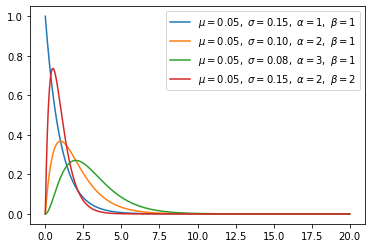

In [26]:
def gamma_function(n):
    cal = 1
    for i in range(2, n):
        cal *= i
    return cal

def gamma(x, a, b):
    c = (b ** a) / gamma_function(a)
    y = c * (x ** (a - 1)) * np.exp(-b * x)
    return x, y, np.mean(y), np.std(y)

for ls in [(1, 1), (2, 1), (3, 1), (2, 2)]:
    a, b = ls[0], ls[1]

    x = np.arange(0, 20, 0.01, dtype=float)
    x, y, u, s = gamma(x, a=a, b=b)
    plt.plot(x, y, label=r'$\mu=%.2f,\ \sigma=%.2f,'
                         r'\ \alpha=%d,\ \beta=%d$' % (u, s, a, b))
plt.legend()
# plt.savefig('graph/gamma.png')
plt.show()

## Exponential distribution(continuous)
Exponential distribution is special cases of the gamma distribution when alpha is 1.

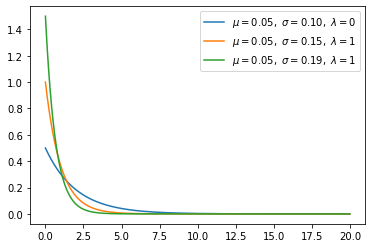

In [28]:
def exponential(x, lamb):
    y = lamb * np.exp(-lamb * x)
    return x, y, np.mean(y), np.std(y)

for lamb in [0.5, 1, 1.5]:

    x = np.arange(0, 20, 0.01, dtype=float)
    x, y, u, s = exponential(x, lamb=lamb)
    plt.plot(x, y, label=r'$\mu=%.2f,\ \sigma=%.2f,'
                         r'\ \lambda=%d$' % (u, s, lamb))
plt.legend()
#plt.savefig('graph/exponential.png')
plt.show()

## Gaussian Distribution(continuous)

Gaussian distribution is the common continuous probability distribution which has a bell curve shape

$$p(x; \mu, \sigma) = \frac{1}{\sqrt(2 \pi \sigma^2)} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

The two parameter gve its a scale $\sigma$ and a location $\mu$.

The standardized form called Normal distribution (z) with 0 mean and 1 std.
$$p(z) = \frac{1}{\sqrt(2 \pi)} e^{-\frac{z^2}{2}}, \quad \text{ where } z = \frac{x-\mu}{\sigma}$$

Handy Formula to work with the exponent to check normalization, mean and variance:

- $I(a) = \int_{-\infty}^{\infty} e^{-ax^2}dx = \sqrt{\frac{\pi}{a}}$
- $\frac{dI(a)}{da} = \int_{-\infty}^{\infty} x^2 e^{-ax^2}dx = \frac{1}{2} \sqrt{\frac{\pi}{a^3}}$

Eg: $ \int_{-\infty}^{\infty} (x^2+1)e^{-x^2/2} dx = 2\sqrt(2\pi)$

Probability in a range computed from CDF,

- $F(z) = \frac{1}{\sqrt(2 \pi)} \int_{-\infty}^z e^{-\frac{z'^2}{2}} dz' = \Phi \left( \frac{x-\mu}{\sigma} \right)$
- $F(b) - F(a) = P(a < Z < b)$


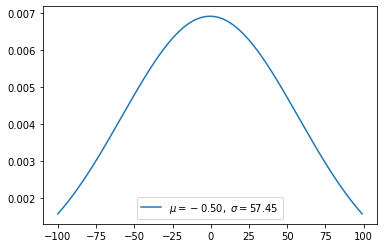

In [29]:
def Gaussian(x, n):
    u = x.mean()
    s = x.std()

    # divide [x.min(), x.max()] by n
    x = np.linspace(x.min(), x.max(), n)

    a = ((x - u) ** 2) / (2 * (s ** 2))
    y = 1 / (s * np.sqrt(2 * np.pi)) * np.exp(-a)

    return x, y, x.mean(), x.std()


def normal(x, n):
    u = x.mean()
    s = x.std()

    # normalization
    x = (x - u) / s

    # divide [x.min(), x.max()] by n
    x = np.linspace(x.min(), x.max(), n)

    a = ((x - 0) ** 2) / (2 * (1 ** 2))
    y = 1 / (s * np.sqrt(2 * np.pi)) * np.exp(-a)

    return x, y, x.mean(), x.std()

x = np.arange(-100, 100) # define range of x
x, y, u, s = Gaussian(x, 10000)   # normal(x, 10000)

plt.plot(x, y, label=r'$\mu=%.2f,\ \sigma=%.2f$' % (u, s))
plt.legend()
#plt.savefig('graph/Gaussian.png')
plt.show()

## Lognormal Distribution

Normal distribution with variable to be log of Random Variable.

$X = \log Y, \quad x = \log y$

then $g(y) = \frac{p(x)}{dy/dx} = \frac{1}{y \sqrt(2 \pi \sigma^2)} e^{-\frac{(log y - \mu)^2}{2\sigma^2}}$

The moments are more easily computed in original variables

$R = e^r - 1$

$\mathbb E[R] = \mathbb E[e^r - 1] = e^{\mu + \sigma^2/2} - 1 \approx \mu + \sigma^2/2 + ...$

$ Var(R) = \mathbb E[(R - \bar R)^2]= e^{2 \mu + \sigma^2} (e^{\sigma^2} - 1) \approx \sigma^2 ( 1 + 2 \mu + ...)$


## Chi-squared distribution(continuous)
Chi-square distribution with k degrees of freedom is the distribution of a sum of the squares of k independent standard normal random variables.
Chi-square distribution is special case of Beta distribution

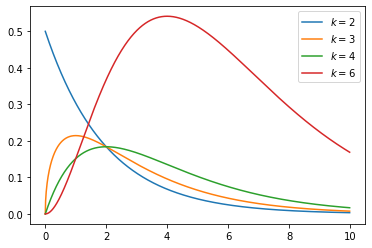

In [31]:
def gamma_function(n):
    cal = 1
    for i in range(2, n):
        cal *= i
    return cal

def chi_squared(x, k):

    c = 1 / (2 ** (k/2)) * gamma_function(k//2)
    y = c * (x ** (k/2 - 1)) * np.exp(-x /2)

    return x, y, np.mean(y), np.std(y)

for k in [2, 3, 4, 6]:
    x = np.arange(0, 10, 0.01, dtype=float)
    x, y, _, _ = chi_squared(x, k)
    plt.plot(x, y, label=r'$k=%d$' % (k))

plt.legend()
#plt.savefig('graph/chi-squared.png')
plt.show()

## Student-t distribution(continuous)
The t-distribution is symmetric and bell-shaped, like the normal distribution, but has heavier tails, meaning that it is more prone to producing values that fall far from its mean.

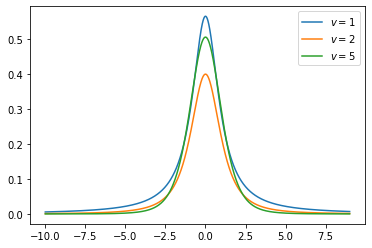

In [33]:
def gamma_function(n):
    cal = 1
    for i in range(2, n):
        cal *= i
    return cal

def student_t(x, freedom, n):

    # divide [x.min(), x.max()] by n
    x = np.linspace(x.min(), x.max(), n)

    c = gamma_function((freedom + 1) // 2) \
        / np.sqrt(freedom * np.pi) * gamma_function(freedom // 2)
    y = c * (1 + x**2 / freedom) ** (-((freedom + 1) / 2))

    return x, y, np.mean(y), np.std(y)

for freedom in [1, 2, 5]:

    x = np.arange(-10, 10) # define range of x
    x, y, _, _ = student_t(x, freedom=freedom, n=10000)
    plt.plot(x, y, label=r'$v=%d$' % (freedom))

plt.legend()
#plt.savefig('graph/student_t.png')
plt.show()

Not all distributions are well behaved, i.e sometimes the moment don't exist, integrals to compute the mean or higher moments diverges, in such cases the CLT may not hold. Eg. Cauchy Distribution have a nice looking bell curve but its not. 

$$p(x) = \frac{A}{\pi^2 A^2 +x^2} \sim \frac{A}{x^2}$$

Even though the probability distribution is fine, the probability sum to 1. But As x gets large it doesn't behave like a Gaussian. Asymptotically  as x goes to + or - infinity the function decreases as 1/x^2 and Integral of this won't converge, it would diverge. 

## Reference
- https://github.com/graykode/distribution-is-all-you-need